In [2]:
import ctypes

import ROOT

from helper_functions import get_QCD_keys, x_sec

In [3]:
top = {}
qcd = {}

with ROOT.TFile.Open("tight_jet_constraint.root","READ") as mc_file:

    temp_h = mc_file.mass.Get("TTbar")
    bin_sel = temp_h.GetXaxis().FindBin("DeltaGr250")
    top["TTto4Q"] = {
        "hist": temp_h.ProjectionY("DGr250",bin_sel,bin_sel),
        "weight": x_sec("TTto4Q") / mc_file.ev.Get("TTbar").GetString().Atof(),
    }
    top["TTto4Q"]["hist"].SetDirectory(ROOT.nullptr)

    for key in get_QCD_keys():

        temp_h = mc_file.mass.Get(key)
        bin_sel = temp_h.GetXaxis().FindBin("DeltaGr250")

        qcd[key] = {
            "hist": temp_h.ProjectionY("DGr250",bin_sel,bin_sel),
            "weight": x_sec(key) / mc_file.ev.Get(key).GetString().Atof(),
                    }
        qcd[key]["hist"].SetDirectory(ROOT.nullptr)

In [36]:
qcd_hist = None

for sec in qcd:

    if qcd_hist is None:
        qcd_hist = qcd[sec]["hist"] * qcd[sec]["weight"]
    else:
        qcd_hist = qcd_hist + qcd[sec]["hist"] * qcd[sec]["weight"]

In [37]:
with ROOT.TFile.Open("data_test.root","READ") as data_file:
    temp_h = data_file.mass.Get("Run2022F_360335-360941_0002")
    bin_sel = temp_h.GetXaxis().FindBin("DeltaGr250")
    data = temp_h.ProjectionY("DGr250",bin_sel,bin_sel)

In [38]:
data.Rebin(30)
qcd_hist.Rebin(30)

Warning in <TH1D::Rebin>: ngroup=30 is not an exact divider of nbins=1000.
Warning in <TH1D::Rebin>: ngroup=30 is not an exact divider of nbins=1000.


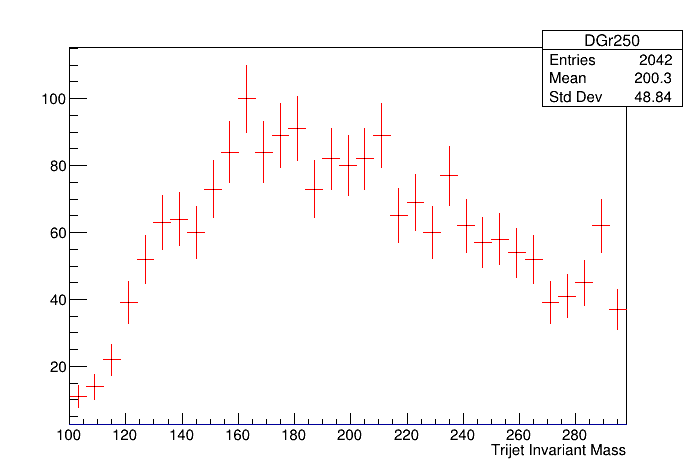

In [53]:
c1 = ROOT.TCanvas()
data.Draw("same")
data.SetLineColor(ROOT.kRed)

qcd_hist.Draw("same HIST")
c1.Draw()